In [1]:
import numpy as np
import matplotlib.pyplot as plt

def rotation_matrix(theta):
    return np.array([[np.cos(theta), -np.sin(theta)],
                     [np.sin(theta), np.cos(theta)]])


def koch_curve(order, L=1):
    koch_vectors = np.array(
        # traces out the koch curve
        [[1, 0], [0, 1], [1, 0], [0, -1], [0, -1], [1, 0], [0, 1]])

    if order == 0:
        return np.array([[0, 0], [1, 0]])

    else:
        points = koch_curve(order - 1)
        new_points = []

        for i in range(len(points) - 1):

            # idea: use rotation matrix to rotate the koch wave vector increments

            p1, p2 = points[i], points[i + 1]
            dist = np.linalg.norm(p2 - p1)
            point_vector = (p2 - p1)
            theta = np.arctan2(point_vector[1], point_vector[0])
            rotation_matrix_theta = rotation_matrix(theta)
            new_points.append(p1)  # include start point of segment

            for j in range(len(koch_vectors)):

                p = new_points[-1] + dist * \
                    rotation_matrix_theta @ (koch_vectors[j]) / 4
                new_points.append(p)

            new_points.append(p2)  # include end point of segment

        return np.array(new_points) * L

In [2]:
def koch_square(order, L=1):
    koch_vectors = np.array(
        # traces out the koch curve
        [[1, 0], [0, 1], [1, 0], [0, -1], [0, -1], [1, 0], [0, 1]])

    if order == 0:
        return np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]])

    else:
        points = koch_square(order - 1)
        new_points = []

        for i in range(len(points) - 1):

            # idea: use rotation matrix to rotate the koch wave vector increments

            p1, p2 = points[i], points[i + 1]
            dist = np.linalg.norm(p2 - p1)
            point_vector = (p2 - p1)
            theta = np.arctan2(point_vector[1], point_vector[0])
            rotation_matrix_theta = rotation_matrix(theta)
            new_points.append(p1)  # include start point of segment

            for j in range(len(koch_vectors)):

                p = new_points[-1] + dist * \
                    rotation_matrix_theta @ (koch_vectors[j]) / 4
                new_points.append(p)

            new_points.append(p2)  # include end point of segment

        return np.array(new_points) * L

# Making the figure for generation of a Koch square

In [3]:
plt.rcParams.update({
    "text.usetex": True,  
    "font.family": "serif",
    "font.serif": ["Times"], 
})

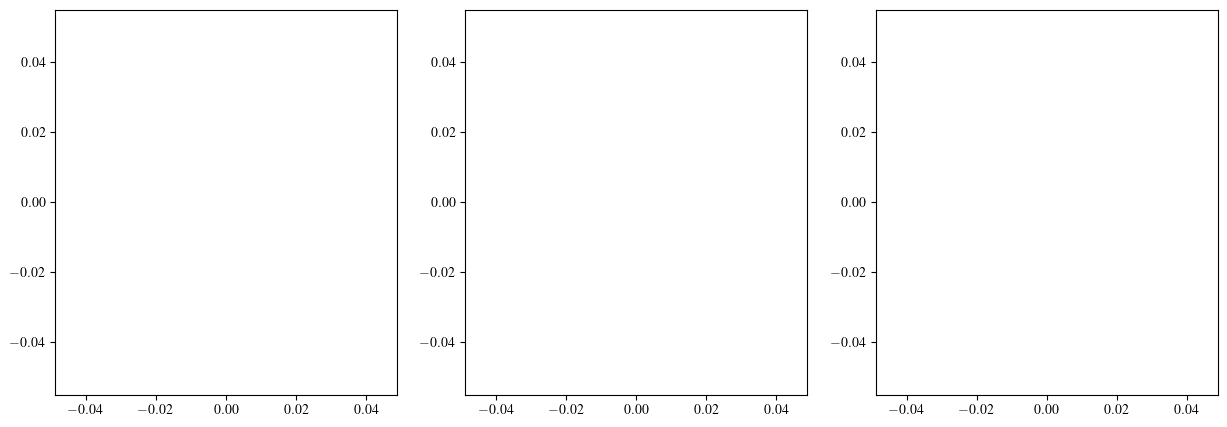

In [4]:
fig, ax = plt.subplots(1,3, figsize=(15, 5))
for a in ax:
    a.axis('equal')

points_0 = koch_curve(0)
points_1 = koch_curve(1)        
points_2 = koch_curve(2)
grid2 = koch_square(1)
grid3 = koch_square(2)

In [5]:
ax[0].plot(points_0[:, 0], points_0[:, 1], 'r--')
ax[0].plot(points_1[:, 0], points_1[:, 1], 'k')
ax[0].set_yticks([])
ax[0].set_xticks([])

[]

In [6]:
ax[1].plot(points_1[:, 0], points_1[:, 1], 'r--')
ax[1].plot(points_2[:, 0], points_2[:, 1], 'k')
ax[1].set_yticks([])   
ax[1].set_xticks([])

[]

In [7]:
ax[2].plot(grid2[:, 0], grid2[:, 1], 'r--')
ax[2].plot(grid3[:, 0], grid3[:, 1], 'k')
ax[2].set_yticks([])
ax[2].set_xticks([])

[]

In [8]:
def black_text(ax,text,xfrac,yfrac,fontsize=30):
    ax.annotate(
    text, xy=(xfrac, yfrac), fontsize=fontsize, color='black',
    xycoords = 'axes fraction'
)

In [9]:
black_text(ax[0], 'a)', 0.03, 0.9)

In [10]:
black_text(ax[1], 'b)', 0.03, 0.9)

In [11]:
black_text(ax[2], 'c)', 0.03, 0.9)

In [12]:
fig.tight_layout()
fig.savefig('koch_curve.png', dpi=300)

## Making figures for eigenmodes

In [13]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from koch_grid import koch_curve
from config import get_path
from visualise import visualise_eigenvector

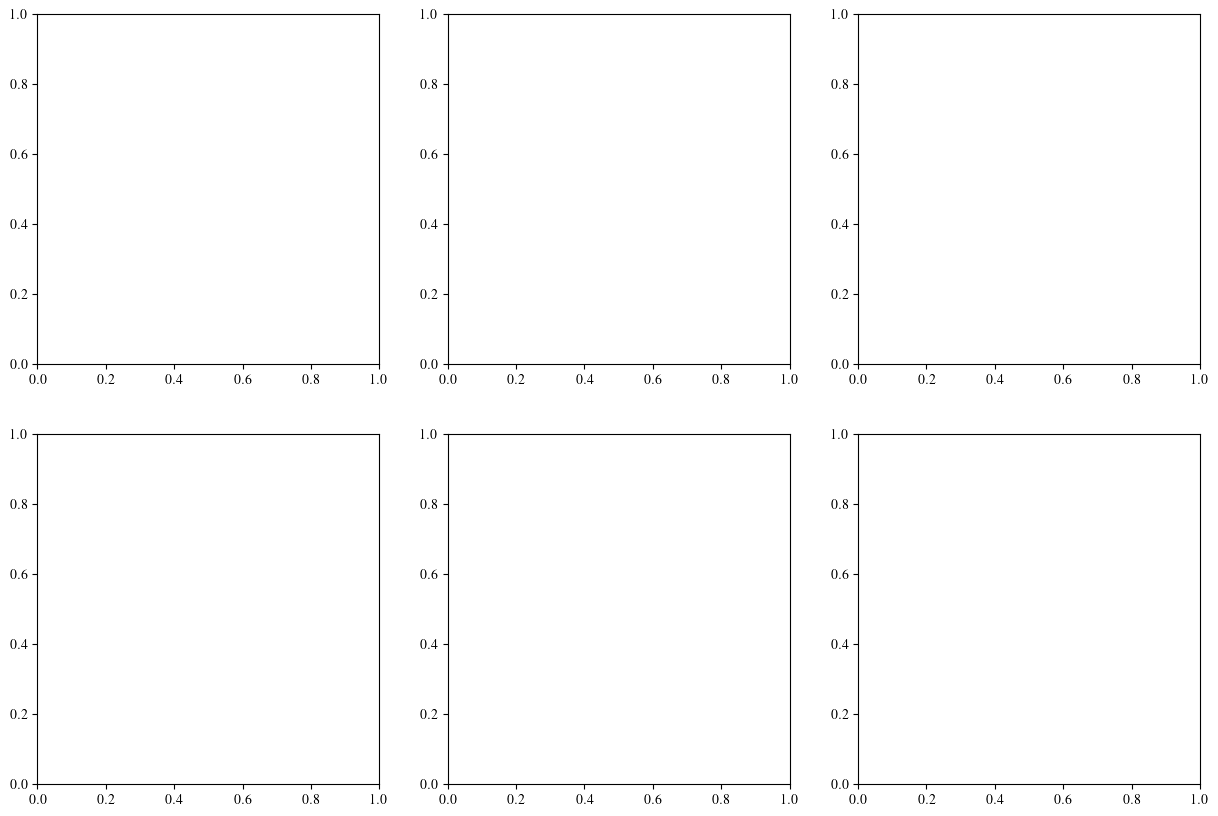

In [14]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))

In [15]:
# plotting 
for i in range(2):
    for j in range(3):
        visualise_eigenvector(5, ax[i, j], i * 3 + j , system = 'normal', pad = 5)

In [16]:
fig.tight_layout()

In [17]:
labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)']

for i in range(2):
    for j in range(3):
        black_text(ax[i, j], labels[i * 3 + j], 0.03, 0.9)

In [18]:
fig.savefig('order_5_eigenvectors.png', dpi=300)

## Making a figure for the biharmonic

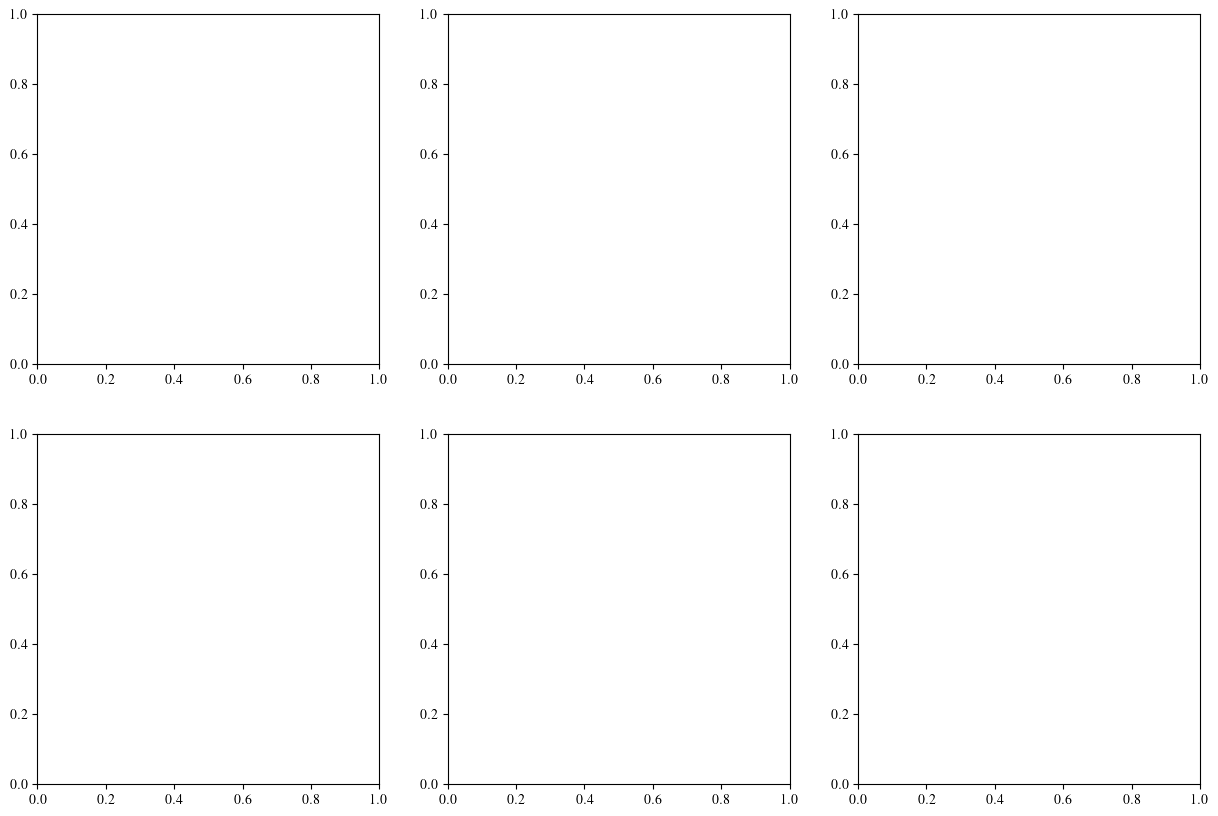

In [19]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))

In [20]:
# plotting 
for i in range(2):
    for j in range(3):
        visualise_eigenvector(5, ax[i, j], i * 3 + j , system = 'biharmonic', pad = 5)

In [21]:
labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)']

In [22]:
fig.tight_layout()

In [23]:
for i in range(2):
    for j in range(3):
        black_text(ax[i, j], labels[i*3 + j], 0.03, 0.9)

In [24]:
fig.savefig('eigenvectors_biharmonic_1_3_5.png', dpi=300)

## Figures for the estimation of d

In [25]:
from finding_parameters import find_d, find_muliple_d

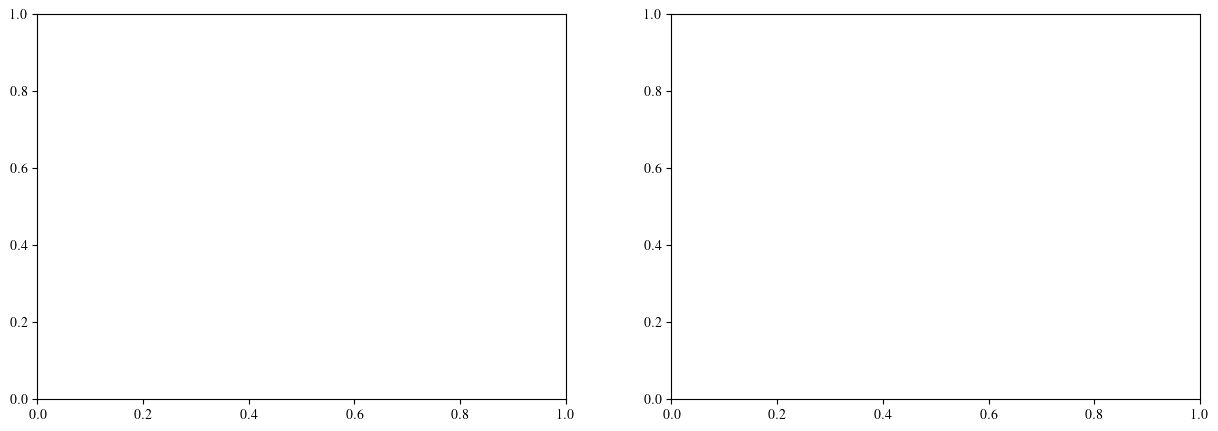

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
labels = ['a)', 'b)']

In [27]:
ax1, ax2 = axs

In [28]:
find_d(order = 4, ax = ax1, system = 'normal', n = 1000)

1.4878618665074956

In [29]:
d3 = find_muliple_d(3, n=1000, system = 'normal')
d4 = find_muliple_d(4, n=1000, system = 'normal')

100%|██████████| 990/990 [00:00<00:00, 1620.21it/s]


In [30]:
ax2.plot(d3, label = r'$\ell = 3$', lw = 2, color = 'blue')
ax2.plot(d4, label = r'$\ell = 4$', lw = 2, color = 'k')
ax2.hlines(1.5, 0, len(d3), color = 'r', linestyle = '--', lw = 2)
ax2.set_ylim(1, 2)

(1.0, 2.0)

In [31]:
labelsize = 30
ticksize = 28
legendsize = 28

In [32]:
ax1.legend(loc = 4, fontsize = legendsize)
ax2.legend(loc = 1, fontsize = legendsize)

ax1.tick_params(axis='both', which='major', labelsize=ticksize)
ax2.tick_params(axis='both', which='major', labelsize=ticksize)

ax1.set_xlabel(r'$\mathrm{\omega}$', fontsize=labelsize)
ax1.set_ylabel(r'$\mathrm{\Delta N(\omega)}$', fontsize =labelsize)

ax2.set_xlabel(r'$\mathrm{\sum \omega_{n}}$', fontsize=labelsize)
ax2.set_ylabel(r'd', fontsize =labelsize)

Text(638.5353535353534, 0.5, 'd')

In [33]:
black_text(ax1, 'a)', 0.03, 0.9)
black_text(ax2, 'b)', 0.03, 0.9)

In [34]:
fig.tight_layout()

In [35]:
fig.savefig('d_vs_omega.png', dpi=300)